In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
X, y_true = make_blobs(n_samples = 500, centers = 3, cluster_std = 0.60, random_state = 42)

In [3]:
df = pd.DataFrame(X, columns = ['feature 1', 'feature 2'])
df

,feature 1,feature 2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [5]:
inertia = []
K_range = range(1, 11)

In [6]:
for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

In [7]:
inertia

[1000.0000000000006,
 297.8954141051723,
 11.575484723104985,
 9.752067977356848,
 8.257175272446279,
 6.917577320416797,
 6.334755391595288,
 5.704177177901426,
 5.060234133532074,
 4.7623618981303935]

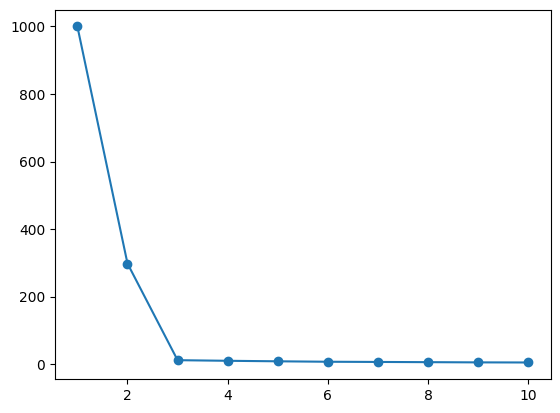

In [8]:
plt.plot(K_range, inertia, marker='o')

In [9]:
kmeans_final = KMeans(n_clusters=3, random_state=42)

In [10]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [11]:
df['cluster'] = cluster_labels

<Axes: xlabel='feature 1', ylabel='feature 2'>

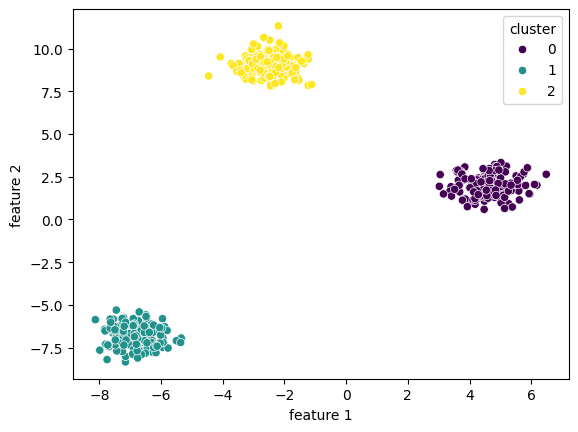

In [12]:
sns.scatterplot(x = df['feature 1'],
                y=df['feature 2'],
                hue=df['cluster'],
                palette='viridis')

In [13]:
from sklearn.datasets import make_moons
X, y_true = make_moons(n_samples = 500, noise = 0.5, random_state = 42)

In [14]:
from sklearn.cluster import KMeans, DBSCAN
